<a href="https://colab.research.google.com/github/Pankhuritrivedi01/Heart_Disease_Prediction_Model/blob/main/Heart_Disease_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
heart_data = pd.read_csv('/content/heart_disease.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", heart_data.shape)

Dataset loaded successfully!
Dataset shape: (303, 14)


In [7]:

display(heart_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:

print("Dataset Information:\n")
heart_data.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:

print("Missing values in each column:\n")
print(heart_data.isnull().sum())

Missing values in each column:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [10]:

duplicate_count = heart_data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


In [11]:

display(heart_data.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:

print("Target value counts:")
print(heart_data['target'].value_counts())

print("\nTarget percentages:")
print(
    (heart_data['target'].value_counts(normalize=True) * 100)
    .round(2)
)

Target value counts:
target
1    165
0    138
Name: count, dtype: int64

Target percentages:
target
1    54.46
0    45.54
Name: proportion, dtype: float64


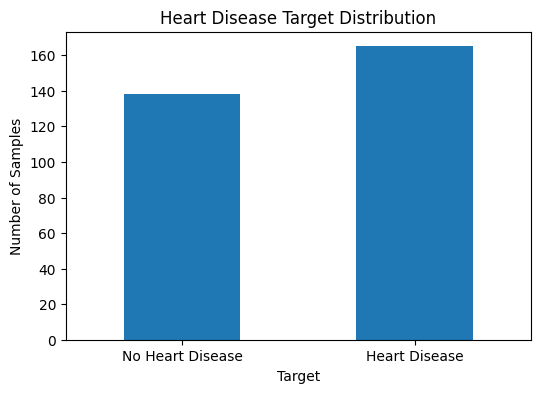

In [13]:

heart_data['target'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=["No Heart Disease", "Heart Disease"],
    rotation=0
)

plt.show()

In [15]:

X = heart_data.drop(columns=['target'])
Y = heart_data['target']

print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (303, 13)
Target shape: (303,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [17]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [18]:

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Model created successfully!")

Model created successfully!


In [19]:

model.fit(X_train_scaled, Y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [20]:

Y_train_pred = model.predict(X_train_scaled)
Y_test_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [21]:

train_accuracy = accuracy_score(Y_train, Y_train_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Training Accuracy: 84.30%


In [22]:

test_accuracy = accuracy_score(Y_test, Y_test_pred)

print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Testing Accuracy: 80.33%


In [23]:

precision = precision_score(Y_test, Y_test_pred)
recall = recall_score(Y_test, Y_test_pred)
f1 = f1_score(Y_test, Y_test_pred)

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

Precision: 76.92%
Recall:    90.91%
F1 Score:  83.33%


In [24]:

print("Classification Report:\n")

print(
    classification_report(
        Y_test,
        Y_test_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

Classification Report:

                  precision    recall  f1-score   support

No Heart Disease       0.86      0.68      0.76        28
   Heart Disease       0.77      0.91      0.83        33

        accuracy                           0.80        61
       macro avg       0.82      0.79      0.80        61
    weighted avg       0.81      0.80      0.80        61



In [25]:

cm = confusion_matrix(Y_test, Y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[19  9]
 [ 3 30]]


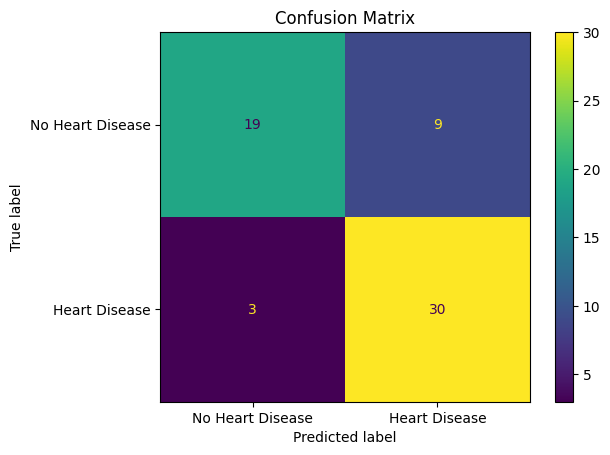

In [26]:

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
).plot()

plt.title("Confusion Matrix")
plt.show()

In [27]:

Y_test_probabilities = model.predict_proba(X_test_scaled)

print("First 5 prediction probabilities:\n")
print(Y_test_probabilities[:5])

First 5 prediction probabilities:

[[0.90840272 0.09159728]
 [0.83839552 0.16160448]
 [0.9938355  0.0061645 ]
 [0.27828814 0.72171186]
 [0.3247437  0.6752563 ]]


In [28]:

Y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 5 Heart Disease probabilities:")
print(Y_test_prob[:5])

First 5 Heart Disease probabilities:
[0.09159728 0.16160448 0.0061645  0.72171186 0.6752563 ]


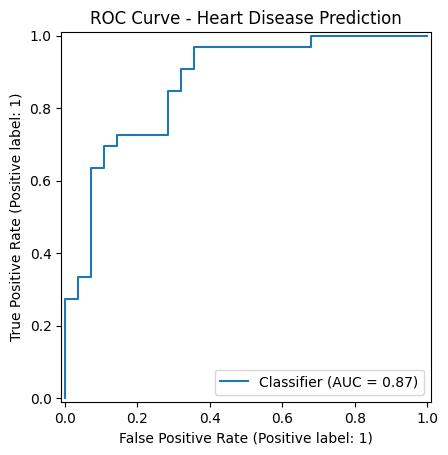

In [29]:

RocCurveDisplay.from_predictions(
    Y_test,
    Y_test_prob
)

plt.title("ROC Curve - Heart Disease Prediction")
plt.show()

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a pipeline
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    cv_pipeline,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy Scores:")
print(cv_scores)

print(f"\nMean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

5-Fold Cross-Validation Accuracy Scores:
[0.7755102  0.81632653 0.8125     0.85416667 0.89583333]

Mean CV Accuracy: 83.09%
Standard Deviation: 4.09%


In [35]:

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

display(feature_importance)

,Feature,Coefficient,Absolute_Coefficient
2,cp,0.937735,0.937735
1,sex,-0.714030,0.714030
12,thal,-0.621578,0.621578
9,oldpeak,-0.594819,0.594819
11,ca,-0.559203,0.559203
7,thalach,0.539629,0.539629
8,exang,-0.475883,0.475883
4,chol,-0.459210,0.459210
10,slope,0.307867,0.307867
6,restecg,0.235471,0.235471


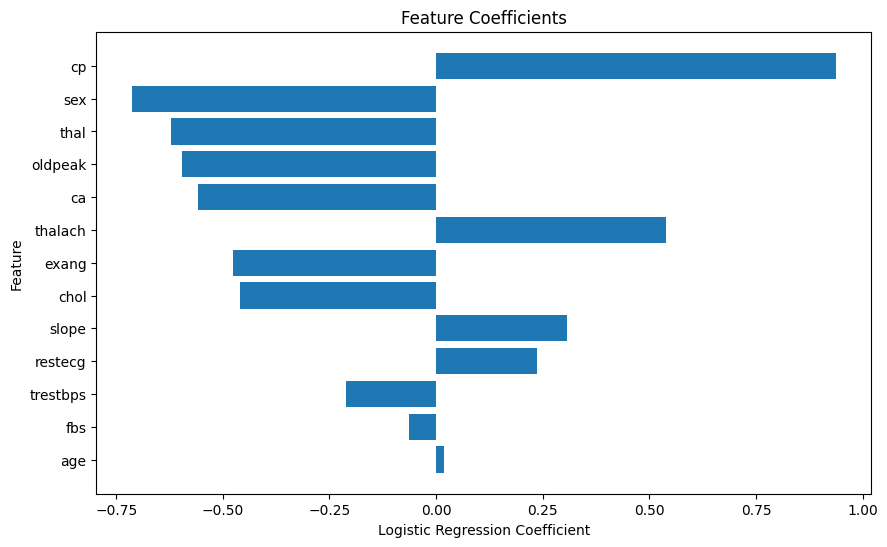

In [36]:

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients")

plt.gca().invert_yaxis()

plt.show()

In [38]:
Y_test_prob = model.predict_proba(X_test_scaled)[:, 1]


roc_auc = roc_auc_score(Y_test, Y_test_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.8690


In [39]:


cv_mean = cv_scores.mean()

performance = pd.DataFrame({
    'Metric': [
        'Training Accuracy',
        'Testing Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        '5-Fold CV Mean Accuracy'
    ],
    'Score': [
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_mean
    ]
})

performance['Score'] = (
    performance['Score'] * 100
).round(2)

display(performance)

,Metric,Score
0,Training Accuracy,84.30
1,Testing Accuracy,80.33
2,Precision,76.92
3,Recall,90.91
4,F1 Score,83.33
5,ROC-AUC,86.90
6,5-Fold CV Mean Accuracy,83.09


In [42]:

def predict_heart_disease(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):

    input_data = pd.DataFrame([[
        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal
    ]], columns=X.columns)


    input_scaled = scaler.transform(input_data)


    prediction = model.predict(input_scaled)[0]


    probabilities = model.predict_proba(input_scaled)[0]

    if prediction == 1:
        result = "Heart Disease"
    else:
        result = "No Heart Disease"

    print("Prediction:", result)
    print(
        f"Probability of No Heart Disease: "
        f"{probabilities[0] * 100:.2f}%"
    )
    print(
        f"Probability of Heart Disease: "
        f"{probabilities[1] * 100:.2f}%"
    )

    return prediction, probabilities

In [43]:

prediction, probability = predict_heart_disease(
    53,    # age
    1,     # sex
    0,     # cp
    140,   # trestbps
    203,   # chol
    1,     # fbs
    0,     # restecg
    155,   # thalach
    1,     # exang
    3.1,   # oldpeak
    0,     # slope
    0,     # ca
    3      # thal
)

Prediction: No Heart Disease
Probability of No Heart Disease: 97.94%
Probability of Heart Disease: 2.06%


In [44]:


def get_prediction_result(input_values):

    input_data = pd.DataFrame(
        [input_values],
        columns=X.columns
    )

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]

    result = {
        "prediction": int(prediction),
        "class": (
            "Heart Disease"
            if prediction == 1
            else "No Heart Disease"
        ),
        "probability_no_heart_disease": round(
            float(probabilities[0]), 4
        ),
        "probability_heart_disease": round(
            float(probabilities[1]), 4
        )
    }

    return result

In [45]:


sample_patient = [
    53,
    1,
    0,
    140,
    203,
    1,
    0,
    155,
    1,
    3.1,
    0,
    0,
    3
]

result = get_prediction_result(sample_patient)

print(result)

{'prediction': 0, 'class': 'No Heart Disease', 'probability_no_heart_disease': 0.9794, 'probability_heart_disease': 0.0206}


In [46]:


cv_mean = cv_scores.mean()

print("=" * 60)
print("HEART DISEASE PREDICTION MODEL SUMMARY")
print("=" * 60)

print(f"Dataset Size            : {heart_data.shape[0]} samples")
print(f"Number of Features      : {X.shape[1]}")
print(f"Training Samples        : {X_train.shape[0]}")
print(f"Testing Samples         : {X_test.shape[0]}")

print("\nModel")
print("-" * 60)
print("Algorithm               : Logistic Regression")
print("Preprocessing            : StandardScaler")
print("Cross-Validation         : 5-Fold")

print("\nPerformance")
print("-" * 60)

print(f"Training Accuracy       : {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy        : {test_accuracy * 100:.2f}%")
print(f"Precision               : {precision * 100:.2f}%")
print(f"Recall                  : {recall * 100:.2f}%")
print(f"F1 Score                : {f1 * 100:.2f}%")
print(f"ROC-AUC                 : {roc_auc:.4f}")
print(f"Mean 5-Fold CV Accuracy : {cv_mean * 100:.2f}%")

print("=" * 60)

HEART DISEASE PREDICTION MODEL SUMMARY
Dataset Size            : 303 samples
Number of Features      : 13
Training Samples        : 242
Testing Samples         : 61

Model
------------------------------------------------------------
Algorithm               : Logistic Regression
Preprocessing            : StandardScaler
Cross-Validation         : 5-Fold

Performance
------------------------------------------------------------
Training Accuracy       : 84.30%
Testing Accuracy        : 80.33%
Precision               : 76.92%
Recall                  : 90.91%
F1 Score                : 83.33%
ROC-AUC                 : 0.8690
Mean 5-Fold CV Accuracy : 83.09%


## Conclusion

A Logistic Regression model was developed to classify heart disease
using 13 clinical and physiological features.

The data was divided into training and testing sets, followed by
feature standardization using StandardScaler. Model performance was
evaluated using accuracy, precision, recall, F1-score, ROC-AUC,
confusion matrix, and 5-fold cross-validation.

Prediction probabilities were also generated to provide additional
information about the model's classification output.

## Disclaimer

This project is developed for educational and research purposes only.
The model is not intended to diagnose, treat, or predict individual
medical outcomes. Predictions should not be used as a substitute for
professional medical advice, diagnosis, or treatment.